In [2]:
# Function to find DBSCAN Clusters
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
def dbcluster(data_array, N_PROC, nn_neighbor, nn_radius, db_min_samples, sensitivity_, eps_threshold_, eps_mode_):
    """
    Perform DBSCAN clustering on a given data array with adaptive epsilon calculation.

    Parameters:
    - data_array: np.ndarray
        Input data with at least 3 columns (x, y, z).
    - N_PROC: int
        Number of processes for parallel computation.
    - nn_neighbor: int
        Number of nearest neighbors for the NearestNeighbors algorithm.
    - nn_radius: float
        Radius for the NearestNeighbors algorithm.
    - db_min_samples: int
        Minimum samples for a cluster in DBSCAN.
    - sensitivity_: float
        Sensitivity for the KneeLocator.
    - eps_threshold_: float
        Threshold below which epsilon defaults to eps_mode_.
    - eps_mode_: float
        Default epsilon value if calculated epsilon is below threshold.

    Returns:
    - labels_: np.ndarray
        Cluster labels from DBSCAN or [-1, -1] in case of failure.
    - valid_cluster: bool
        True if clustering is successful, False otherwise.
    - epsilon_: float
        The epsilon value used for DBSCAN.
    """
    valid_cluster = True
    epsilon_ = 0  # Default epsilon value
    try:
        # Extract the first three columns (x, y, z)
        extractedData = data_array[:, 0:2 + 1]

        # Nearest neighbors setup
        neigh = NearestNeighbors(n_neighbors=nn_neighbor, radius=nn_radius)
        nbrs = neigh.fit(extractedData)
        distances, indices = nbrs.kneighbors(extractedData)
        distances = np.sort(distances, axis=0)
        dist_ = distances[:, nn_neighbor-1]
        # dist_ = distances[:, 1]

        # KneeLocator to find the optimal epsilon
        kneedle = KneeLocator(
            x = np.arange(len(dist_)),
            y=dist_,
            S=sensitivity_,
            curve='convex',
            direction='increasing',
            interp_method='interp1d'
        )
        if kneedle.knee is None:
            raise ValueError("KneeLocator failed to identify a knee point.")

        epsilon_ = round(dist_[int(kneedle.knee)], 2)
        if epsilon_ < eps_threshold_:
            print('EPSILON BELOW THRESHOLD, USING DEFAULT', eps_mode_, epsilon_)
            epsilon_ = eps_mode_
        else:
            print('USING EPSILON', epsilon_)
        # DBSCAN clustering
        model = DBSCAN(eps=epsilon_, min_samples=db_min_samples, n_jobs=N_PROC)
        labels_ = model.fit_predict(extractedData)
        return labels_, valid_cluster, epsilon_

    except ValueError as ve:
        print(f"ValueError: {ve}")
    except Exception as e:
        print(f"Error: {e}")

    # Return defaults in case of failure
    return np.array([-1, -1]), False, epsilon_

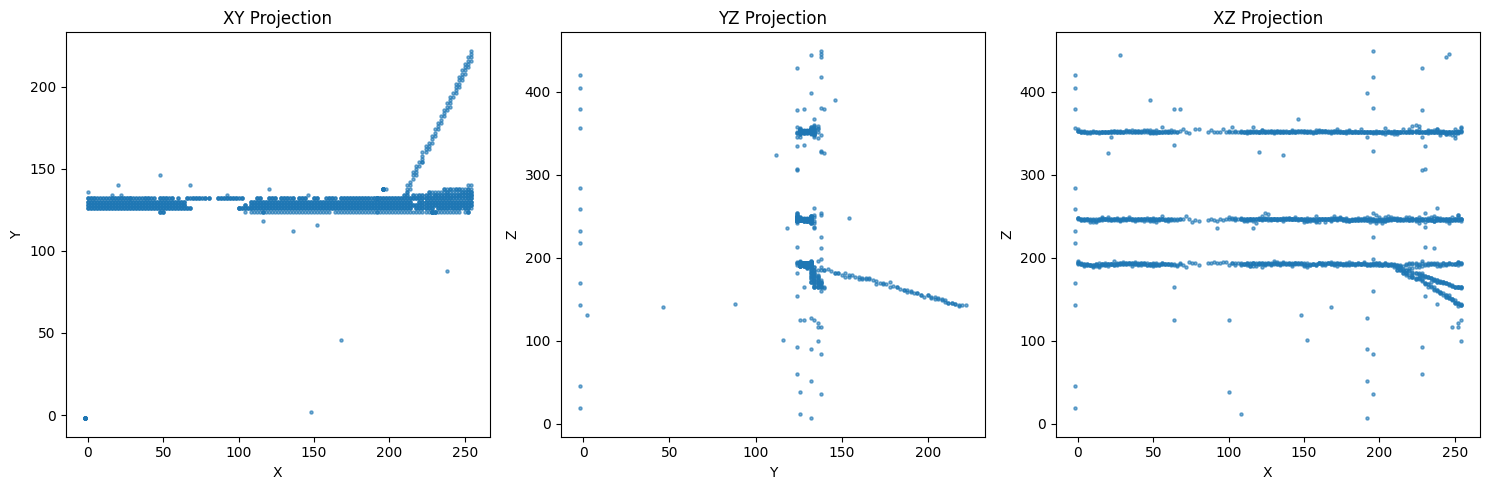

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.load('exp_event_21_run_53.npy')

# Extract coordinates
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# XY projection
axs[0].scatter(x, y, s=5, alpha=0.6)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('XY Projection')

# YZ projection
axs[1].scatter(y, z, s=5, alpha=0.6)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title('YZ Projection')

# XZ projection
axs[2].scatter(x, z, s=5, alpha=0.6)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title('XZ Projection')

plt.tight_layout()
plt.show()

In [4]:
dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,6,20,6,3,4,7)

USING EPSILON 8.05


In [5]:
def plot_dbscan_results(data, labels_, dist_, kneedle, epsilon_):
    """
    Plot Kneedle curve (for epsilon detection) and 2D projections with DBSCAN labels.
    
    Parameters:
    - data: np.ndarray of shape (n_samples, 3)
    - labels_: cluster labels from DBSCAN
    - dist_: sorted nearest-neighbor distance array
    - kneedle: fitted KneeLocator object
    - epsilon_: epsilon chosen for DBSCAN
    """
    unique_labels = set(labels_)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # --- Plot 1: Kneedle distance curve ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(dist_)), dist_, marker=".", alpha=0.6)
    if kneedle.knee is not None:
        plt.axvline(kneedle.knee, color="r", linestyle="--", label=f"knee={kneedle.knee}")
        plt.axhline(epsilon_, color="g", linestyle="--", label=f"eps={epsilon_}")
    plt.title("Kneedle distance curve")
    plt.xlabel("Points sorted by distance")
    plt.ylabel("k-NN distance")
    plt.yscale('log')
    plt.ylim(0, 20)
    plt.legend()

    # --- Plot 2: 2D projection with DBSCAN clusters ---
    plt.subplot(1, 2, 2)
    for k, col in zip(unique_labels, colors):        
        if k in [1, 2, 3, 4]:
            continue
        if k == -1:
            # Noise
            col = "k"
            size = 10
        else:
            size = 40
        xy = data[labels_ == k]
        print(k, len(xy[:, 0]))
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=size, label=f"Cluster {k}" if k != -1 else "Noise", alpha=0.6)

    plt.title("DBSCAN clustering (2D projection)")
    plt.xlabel("X")
    plt.ylabel("Y")    
    plt.legend()
    plt.tight_layout()
    plt.show()

USING EPSILON 8.05
0 548
-1 68


C:\Users\alarokia\AppData\Local\Temp\ipykernel_29860\1330074114.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 20)


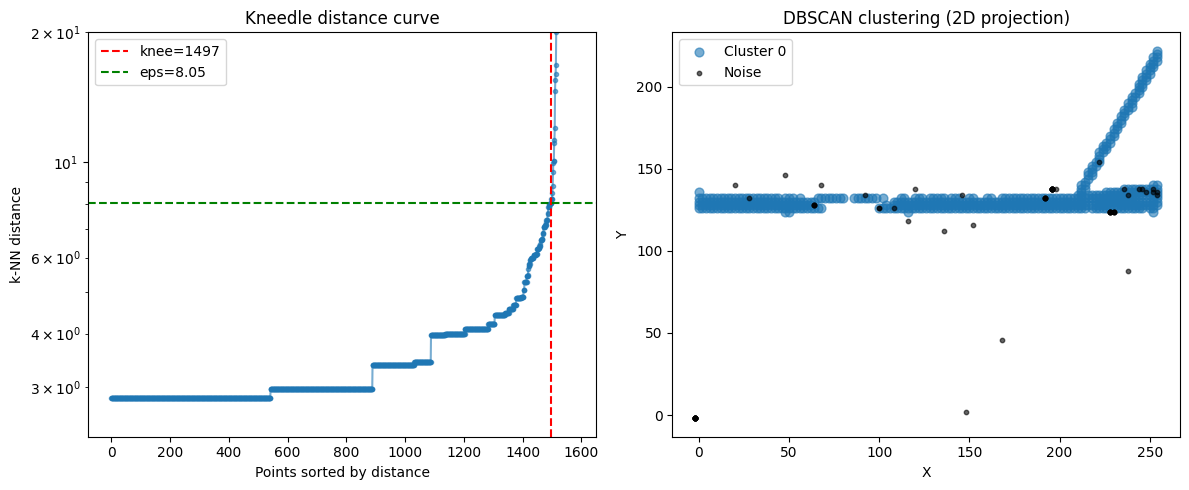

In [6]:
dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,6,20,6,3,4,7)
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

neigh = NearestNeighbors(n_neighbors=6)
distances, _ = neigh.fit(data[:, :3]).kneighbors(data[:, :3])
distances = np.sort(distances, axis=0)
dist_ = distances[:, 5]

kneedle = KneeLocator(
    x=np.arange(len(dist_)),
    y=dist_,
    S=3,
    curve="convex",
    direction="increasing",
    interp_method='interp1d'
)

# Call plotting function
plot_dbscan_results(data, dbscan_labels, dist_, kneedle, epsilon_)

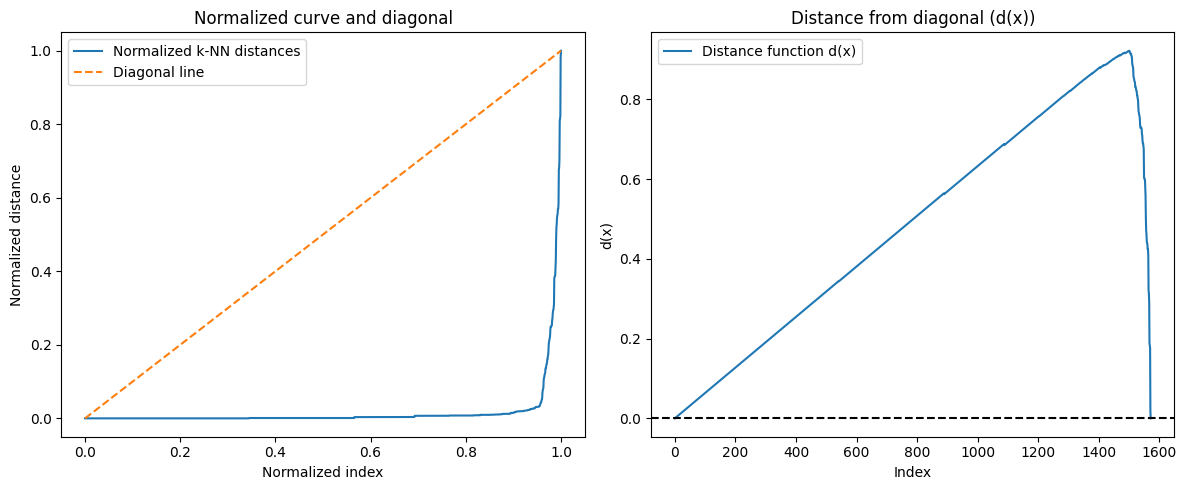

Approx elbow index: 1500, distance: 0.922385229765425


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

def plot_kneedle_distance(distances, S=1.0):
    # Sort distances (already done in your code)
    x = np.arange(len(distances))
    y = distances

    # Normalize x and y to [0,1]
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Diagonal line
    diag = x_norm  # for convex, increasing curve

    # Distance from diagonal
    d = diag - y_norm


    # Plot distance from diagonal
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(x_norm, y_norm, label="Normalized k-NN distances")
    plt.plot(x_norm, diag, '--', label="Diagonal line")
    plt.title("Normalized curve and diagonal")
    plt.xlabel("Normalized index")
    plt.ylabel("Normalized distance")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(x, d, label="Distance function d(x)")
    plt.title("Distance from diagonal (d(x))")
    plt.xlabel("Index")
    plt.ylabel("d(x)")
    plt.axhline(0, color="k", linestyle="--")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Optional: show approximate elbow
    peak_idx = np.argmax(d)
    # print(np.max(d), np.min(d), np.mean(d))
    # peak_idx = np.argmax(d[1:]) + 1  # skip index 0
    print(f"Approx elbow index: {peak_idx}, distance: {d[peak_idx]}")

# Call it
plot_kneedle_distance(dist_)


In [8]:
from sklearn.mixture import GaussianMixture
# Function to do the GMM Fitting
def fit_gmm_with_bic(data, max_components=10, cluster_id = None):
    """
    Fit Gaussian Mixture Model using BIC to select optimal components.

    Parameters:
    - data (np.ndarray): Input data array with shape (n_samples, 6) where columns are x, y, z, q, true labels, ransac labels, gmm labels.
    - max_components (int): Maximum number of GMM components to evaluate for BIC score.

    Returns:
    - best_labels (np.ndarray): Labels assigned to each data point for the GMM model with the lowest BIC.
    - best_n_components (int): Number of components in the best GMM model according to BIC.
    """
    # Extract features (first 3 columns: x, y, z, q)
    features = data[:, :3]

    best_bic = np.inf
    best_gmm = None
    best_n_components = 1

    
    for n_components in range(1, max_components + 1):
        n_samples = features.shape[0]
        if n_components > features.shape[0]:
            break  # Exit loop early if n_components exceeds n_samples
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(features)
        bic = gmm.bic(features)
        if cluster_id == 0:
            print(n_components, bic)
        # Check if this model has the lowest BIC
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_n_components = n_components

    # Fit the best GMM model and predict labels
    best_labels = best_gmm.predict(features)
    responsibilities = best_gmm.predict_proba(features)

    return best_labels, best_n_components, responsibilities

In [9]:
# Function to do GMM clustering for every dbscan cluster
def hierarchical_clustering_with_responsibilities(data_array, max_components=10):
    """
    Perform DBSCAN clustering and then apply GMM clustering to each DBSCAN cluster,
    computing the responsibility array for all data points.

    Parameters:
    - data_array (np.ndarray): Input data array with at least 3 columns (x, y, z).
    - max_components (int): Maximum number of GMM components to evaluate for BIC.

    Returns:
    - final_labels (np.ndarray): Combined labels for the entire dataset after hierarchical clustering.
    - dbscan_labels (np.ndarray): Labels from the DBSCAN clustering.
    - final_responsibilities (np.ndarray): Responsibility matrix of shape (n_points, total_gmm_clusters).
    """
    # Step 1: Perform DBSCAN clustering   
    dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,6,20,6,3,4,7)

    if not valid_cluster:
        print("DBSCAN clustering failed.")
        return np.array([-1] * len(data_array)), dbscan_labels, None

    unique_clusters = np.unique(dbscan_labels)
    num_points = len(data_array)

    final_labels = -1 * np.ones(num_points, dtype=int)
    final_responsibilities = -1 * np.ones((num_points, 0))

    current_label_offset = 0

    for cluster_id in unique_clusters:
        if cluster_id == -1:
            continue

        cluster_mask = dbscan_labels == cluster_id
        cluster_data = data_array[cluster_mask]

        gmm_labels, n_comp, responsibilities = fit_gmm_with_bic(cluster_data, max_components=max_components, cluster_id = cluster_id)

        global_gmm_labels = gmm_labels + current_label_offset
        final_labels[cluster_mask] = global_gmm_labels

        new_responsibilities = -1 * np.ones((num_points, n_comp))
        new_responsibilities[cluster_mask, :] = responsibilities
        final_responsibilities = np.hstack((final_responsibilities, new_responsibilities))

        current_label_offset += n_comp

    return final_labels, current_label_offset, final_responsibilities, dbscan_labels


In [10]:
gmm_labels, n_comp, responsibilities, dbscan_labels = hierarchical_clustering_with_responsibilities(data, max_components=10)

USING EPSILON 8.05
1 14490.161268877322
2 11369.46993067093
3 11272.175905705737
4 10771.267893853656
5 10798.475797824169
6 10819.442539263271
7 10825.738536486697
8 10829.385758674314
9 10847.449069767792
10 10857.205025841238


In [11]:
print(gmm_labels.shape, dbscan_labels.shape, responsibilities.shape, data.shape)

(1572,) (1572,) (1572, 25) (1572, 4)


In [12]:
# Boolean mask for cluster 0
mask = (dbscan_labels == 0)

# Apply mask to all aligned arrays
gmm_labels_0 = gmm_labels[mask]
dbscan_labels_0 = dbscan_labels[mask]
responsibilities_0 = responsibilities[mask]
data_0 = data[mask]
np.savetxt("cluster_0_data.txt", data_0, fmt="%.6f")

# --- Step 1: Boolean mask for cluster 0 and noise (-1) ---
labels_1 = (dbscan_labels == 0) | (dbscan_labels == -1)

# --- Step 2: Apply mask to all arrays ---
gmm_labels_1 = gmm_labels[labels_1]
dbscan_labels_1 = dbscan_labels[labels_1]
responsibilities_1 = responsibilities[labels_1]
data_1 = data[labels_1]


C:\Users\alarokia\AppData\Local\Temp\ipykernel_29860\429188347.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique_labels))
C:\Users\alarokia\AppData\Local\Temp\ipykernel_29860\429188347.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


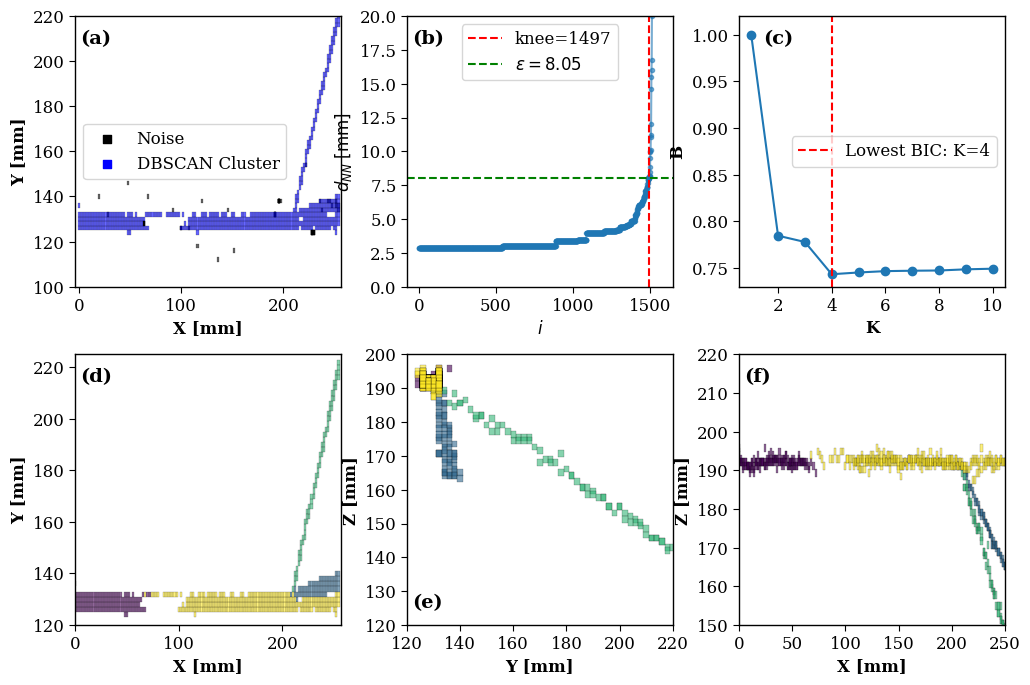

In [13]:
from matplotlib.patches import Rectangle
from matplotlib import rcParams

# Unpack axes
X, Y, Z = data_0[:, 0], data_0[:, 1], data_0[:, 2]

# Function to plot squares in a given axes
def plot_squares(ax, X_data, Y_data, labels, cmap='viridis'):
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap(cmap, len(unique_labels))
    
    for k in unique_labels:
        subset_X = X_data[labels == k]
        subset_Y = Y_data[labels == k]
        for x, y in zip(subset_X, subset_Y):
            rect = Rectangle(
                (x - 1, y - 1),  # bottom-left corner; 2mm square
                2, 2,             # width, height in data units
                facecolor=colors(k) if k != -1 else 'k',
                edgecolor='k',
                alpha=0.6,
                linewidth=0.2
            )
            ax.add_patch(rect)
    
    # ax.set_aspect('equal')  # ensure squares look square
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel(ax.get_ylabel())

# --- GLOBAL STYLE FOR NIMA-STYLE PLOTS ---
rcParams["font.size"] = 12
rcParams["font.family"] = "serif"
rcParams["axes.labelweight"] = "bold"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.major.size"] = 4
rcParams["ytick.major.size"] = 4

# ---- FIGURE SHAPE (KEY PART) ----
# NIMA likes wide figures with evenly sized panels
fig = plt.figure(figsize=(10, 7))

# Define grid with controlled spacing
gs = fig.add_gridspec(
    2, 3,
    left=0.05, right=0.98, top=0.95, bottom=0.08,
    wspace=0.25, hspace=0.25
)

axes = np.empty((2,3), dtype=object)

for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])
        
# Create figure and subplots
# fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

# PLOT 1
axes[0, 1].plot(np.arange(len(dist_)), dist_, marker=".", alpha=0.6)
if kneedle.knee is not None:
    axes[0, 1].axvline(kneedle.knee, color="r", linestyle="--", label=f"knee={kneedle.knee}")
    axes[0, 1].axhline(epsilon_, color="g", linestyle="--", label=rf"$\epsilon = {epsilon_:.2f}$")
axes[0, 1].set_xlabel(r"$i$", fontweight='bold')
axes[0, 1].set_ylabel(r"$d_{NN}\ [\mathrm{mm}]$", fontweight='bold')
axes[0, 1].set_ylim(0, 20)
axes[0, 1].legend()

# PLOT 2
unique_labels = np.unique(dbscan_labels_1)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
axes[0, 0].cla()
# Plot squares
for k, col in zip(unique_labels, colors):
    subset = data_1[dbscan_labels_1 == k]
    xy_subset = subset[:, :2]  # first two columns: X, Y

    for x, y in xy_subset:
        if k == -1:
            color = 'k'
        else:
            color = 'blue'
        # Rectangle in data coordinates, width=height=2 mm
        rect = Rectangle(
            (x-1, y-1),   # bottom-left corner
            2, 2,         # width, height
            facecolor= color,
            edgecolor='k',   # black border
            linewidth=0.2,   # optional, thickness of the border
            alpha=0.6
        )
        axes[0, 0].add_patch(rect)

# --- Adjust axes limits and aspect ---
axes[0, 0].set_xlim(np.min(data_1[:, 0]) - 2, np.max(data_1[:, 0]) + 2)
axes[0, 0].set_ylim(100, 220)
# axes[0, 0].set_ylim(125, 150)
# axes[0, 0].set_ylim(np.min(data_1[:, 1]) - 2, np.max(data_1[:, 1]) + 2)
# axes[0, 0].set_aspect('equal')  # Ensure squares look square
axes[0, 0].set_xlabel("X [mm]", fontweight='bold')
axes[0, 0].set_ylabel("Y [mm]", fontweight='bold')

# Optional: legend (simplified)
axes[0, 0].scatter([], [], c='k', marker='s', label='Noise')
axes[0, 0].scatter([], [], c='blue', marker='s', label='DBSCAN Cluster')
axes[0, 0].legend()

# PLOT - 3

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
b = np.array([14490.161268877322, 11369.46993067093, 11272.175905705737,
              10771.267893853656, 10798.475797824169, 10819.442539263271,
              10825.738536486697, 10829.385758674314, 10847.449069767792,
              10857.205025841238])

# Normalize BIC by the first value
bic_normalized = b / b[0]

# Plot BIC vs K
axes[0, 2].plot(a, bic_normalized, marker='o')
axes[0, 2].set_xlabel('K', fontweight='bold')
axes[0, 2].set_ylabel('B', fontweight='bold')
axes[0, 2].set_ylim(0.73, 1.02)

# Find K corresponding to lowest BIC
min_index = np.argmin(b)
min_K = a[min_index]

# Plot vertical line at lowest BIC
axes[0, 2].axvline(x=min_K, color='r', linestyle='--', label=f'Lowest BIC: K={min_K}')
axes[0, 2].legend()


# # XY plot
# axes[1, 0].scatter(X, Y, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 0].set_xlabel('X')
# axes[1, 0].set_ylabel('Y')
# axes[1, 0].set_title('XY Projection')

# # YZ plot
# axes[1, 1].scatter(Y, Z, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 1].set_xlabel('Y')
# axes[1, 1].set_ylabel('Z')
# axes[1, 1].set_title('YZ Projection')

# # XZ plot
# axes[1, 2].scatter(X, Z, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 2].set_xlabel('X')
# axes[1, 2].set_ylabel('Z')
# axes[1, 2].set_title('XZ Projection')

# XY Projection
axes[1, 0].cla()
plot_squares(axes[1, 0], X, Y, gmm_labels_0)
axes[1, 0].set_xlabel('X [mm]', fontweight='bold')
axes[1, 0].set_ylabel('Y [mm]', fontweight='bold')
axes[1, 0].set_xlim(0, 256)
axes[1, 0].set_ylim(120, 225)


# YZ Projection
axes[1, 1].cla()
plot_squares(axes[1, 1], Y, Z, gmm_labels_0)
axes[1, 1].set_xlabel('Y [mm]', fontweight='bold')
axes[1, 1].set_ylabel('Z [mm]', fontweight='bold')
axes[1, 1].set_xlim(120, 220)
axes[1, 1].set_ylim(120, 200)

# XZ Projection
axes[1, 2].cla()
plot_squares(axes[1, 2], X, Z, gmm_labels_0)
axes[1, 2].set_xlabel('X [mm]', fontweight='bold')
axes[1, 2].set_ylabel('Z [mm]', fontweight='bold')
axes[1, 2].set_xlim(0, 250)
axes[1, 2].set_ylim(150, 220)

# Letters for 2x3 grid
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
axes_flat = axes.ravel()

# Default positions for all labels
default_pos = (0.02, 0.95)  # top-left

for i, (ax, label) in enumerate(zip(axes_flat, subplot_labels)):
    # Set custom positions
    if label == '(c)':
        x, y = 0.09, 0.95  # shifted a bit to the right
    elif label == '(e)':
        x, y = 0.02, 0.05  # bottom-left
    else:
        x, y = default_pos
    
    ax.text(
        x, y,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top' if y > 0.5 else 'bottom',
        ha='left'
    )
    
# Layout and show
# Save figure as PNG with 300 dpi
plt.tight_layout()
# fig.subplots_adjust(hspace=0.4)  # increase space between rows
# fig.savefig("b_dbscan_backup.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
pip install pylustrator

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pylustrator
pylustrator.start()  # start interactive mode

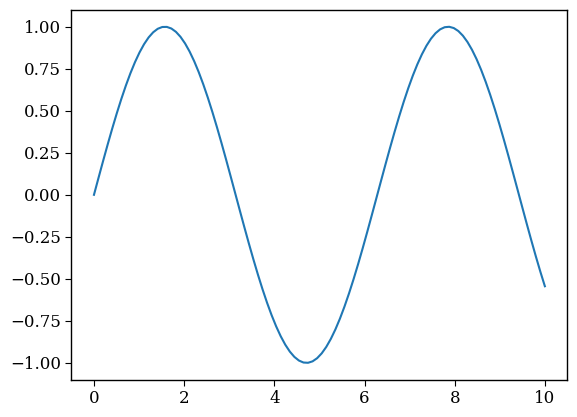

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

C:\Users\alarokia\AppData\Local\Temp\ipykernel_29860\1386186003.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique_labels))


(548,) (548,)


C:\Users\alarokia\AppData\Local\Temp\ipykernel_29860\1386186003.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


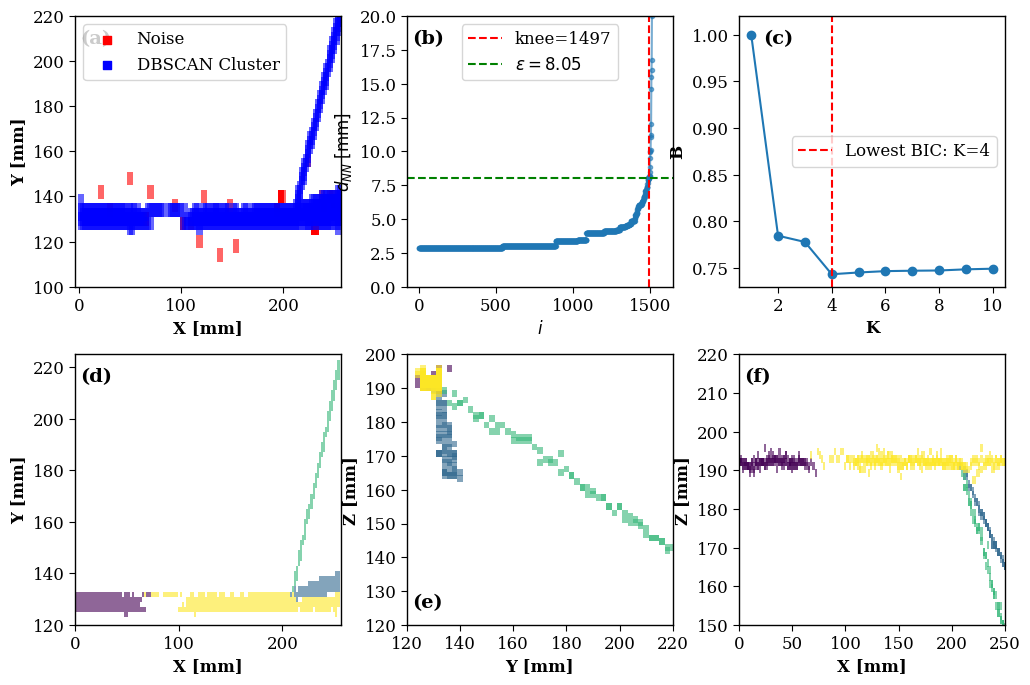

In [22]:
from matplotlib.patches import Rectangle
from matplotlib import rcParams
# pylustrator.start()
# Unpack axes
X, Y, Z = data_0[:, 0], data_0[:, 1], data_0[:, 2]

# Function to plot squares in a given axes
def plot_squares(ax, X_data, Y_data, labels, cmap='viridis'):
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap(cmap, len(unique_labels))
    
    for k in unique_labels:
        subset_X = X_data[labels == k]
        subset_Y = Y_data[labels == k]
        for x, y in zip(subset_X, subset_Y):
            rect = Rectangle(
                (x - 1, y - 1),  # bottom-left corner; 2mm square
                2, 2,             # width, height in data units
                facecolor=colors(k) if k != -1 else 'k',
                edgecolor='none',
                alpha=0.6,
                linewidth=0.0
            )
            ax.add_patch(rect)
    
    # ax.set_aspect('equal')  # ensure squares look square
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel(ax.get_ylabel())

# --- GLOBAL STYLE FOR NIMA-STYLE PLOTS ---
rcParams["font.size"] = 12
rcParams["font.family"] = "serif"
rcParams["axes.labelweight"] = "bold"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.major.size"] = 4
rcParams["ytick.major.size"] = 4

# ---- FIGURE SHAPE (KEY PART) ----
# NIMA likes wide figures with evenly sized panels
fig = plt.figure(figsize=(10, 7))

# Define grid with controlled spacing
gs = fig.add_gridspec(
    2, 3,
    left=0.05, right=0.98, top=0.95, bottom=0.08,
    wspace=0.25, hspace=0.25
)

axes = np.empty((2,3), dtype=object)

for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])
        
# Create figure and subplots
# fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

# PLOT 1
axes[0, 1].plot(np.arange(len(dist_)), dist_, marker=".", alpha=0.6)
if kneedle.knee is not None:
    axes[0, 1].axvline(kneedle.knee, color="r", linestyle="--", label=f"knee={kneedle.knee}")
    axes[0, 1].axhline(epsilon_, color="g", linestyle="--", label=rf"$\epsilon = {epsilon_:.2f}$")
axes[0, 1].set_xlabel(r"$i$", fontweight='bold')
axes[0, 1].set_ylabel(r"$d_{NN}\ [\mathrm{mm}]$", fontweight='bold')
axes[0, 1].set_ylim(0, 20)
axes[0, 1].legend()

# PLOT 2
unique_labels = np.unique(dbscan_labels_1)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
axes[0, 0].cla()
# Plot squares
for k, col in zip(unique_labels, colors):
    subset = data_1[dbscan_labels_1 == k]
    xy_subset = subset[:, :2]  # first two columns: X, Y

    for x, y in xy_subset:
        if k == -1:
            color = 'red'
        else:
            color = 'blue'
        # Rectangle in data coordinates, width=height=2 mm
        rect = Rectangle(
            (x-1, y-1),   # bottom-left corner
            6, 6,         # width, height
            facecolor= color,
            edgecolor='none',   # black border
            linewidth=0.0,   # optional, thickness of the border
            alpha=0.6
        )
        axes[0, 0].add_patch(rect)

# --- Adjust axes limits and aspect ---
axes[0, 0].set_xlim(np.min(data_1[:, 0]) - 2, np.max(data_1[:, 0]) + 2)
axes[0, 0].set_ylim(100, 220)
# axes[0, 0].set_ylim(125, 150)
# axes[0, 0].set_ylim(np.min(data_1[:, 1]) - 2, np.max(data_1[:, 1]) + 2)
# axes[0, 0].set_aspect('equal')  # Ensure squares look square
axes[0, 0].set_xlabel("X [mm]", fontweight='bold')
axes[0, 0].set_ylabel("Y [mm]", fontweight='bold')

# Optional: legend (simplified)
axes[0, 0].scatter([], [], c='red', marker='s', label='Noise')
axes[0, 0].scatter([], [], c='blue', marker='s', label='DBSCAN Cluster')
axes[0, 0].legend()

# PLOT - 3

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
b = np.array([14490.161268877322, 11369.46993067093, 11272.175905705737,
              10771.267893853656, 10798.475797824169, 10819.442539263271,
              10825.738536486697, 10829.385758674314, 10847.449069767792,
              10857.205025841238])

# Normalize BIC by the first value
bic_normalized = b / b[0]

# Plot BIC vs K
axes[0, 2].plot(a, bic_normalized, marker='o')
axes[0, 2].set_xlabel('K', fontweight='bold')
axes[0, 2].set_ylabel('B', fontweight='bold')
axes[0, 2].set_ylim(0.73, 1.02)

# Find K corresponding to lowest BIC
min_index = np.argmin(b)
min_K = a[min_index]

# Plot vertical line at lowest BIC
axes[0, 2].axvline(x=min_K, color='r', linestyle='--', label=f'Lowest BIC: K={min_K}')
axes[0, 2].legend()


# # XY plot
# axes[1, 0].scatter(X, Y, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 0].set_xlabel('X')
# axes[1, 0].set_ylabel('Y')
# axes[1, 0].set_title('XY Projection')

# # YZ plot
# axes[1, 1].scatter(Y, Z, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 1].set_xlabel('Y')
# axes[1, 1].set_ylabel('Z')
# axes[1, 1].set_title('YZ Projection')

# # XZ plot
# axes[1, 2].scatter(X, Z, c=gmm_labels_0, cmap='viridis', s=25)
# axes[1, 2].set_xlabel('X')
# axes[1, 2].set_ylabel('Z')
# axes[1, 2].set_title('XZ Projection')

# XY Projection
axes[1, 0].cla()
plot_squares(axes[1, 0], X, Y, gmm_labels_0)
axes[1, 0].set_xlabel('X [mm]', fontweight='bold')
axes[1, 0].set_ylabel('Y [mm]', fontweight='bold')
axes[1, 0].set_xlim(0, 256)
axes[1, 0].set_ylim(120, 225)


# YZ Projection
axes[1, 1].cla()
plot_squares(axes[1, 1], Y, Z, gmm_labels_0)
axes[1, 1].set_xlabel('Y [mm]', fontweight='bold')
axes[1, 1].set_ylabel('Z [mm]', fontweight='bold')
axes[1, 1].set_xlim(120, 220)
axes[1, 1].set_ylim(120, 200)

# XZ Projection
axes[1, 2].cla()
print(X.shape, Z.shape)
plot_squares(axes[1, 2], X, Z, gmm_labels_0)
axes[1, 2].set_xlabel('X [mm]', fontweight='bold')
axes[1, 2].set_ylabel('Z [mm]', fontweight='bold')
axes[1, 2].set_xlim(0, 250)
axes[1, 2].set_ylim(150, 220)

# Letters for 2x3 grid
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
axes_flat = axes.ravel()

# Default positions for all labels
default_pos = (0.02, 0.95)  # top-left

for i, (ax, label) in enumerate(zip(axes_flat, subplot_labels)):
    # Set custom positions
    if label == '(c)':
        x, y = 0.09, 0.95  # shifted a bit to the right
    elif label == '(e)':
        x, y = 0.02, 0.05  # bottom-left
    else:
        x, y = default_pos
    
    ax.text(
        x, y,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top' if y > 0.5 else 'bottom',
        ha='left'
    )
    
# Layout and show
# Save figure as PNG with 300 dpi
plt.tight_layout()
# fig.subplots_adjust(hspace=0.4)  # increase space between rows
# fig.savefig("b_dbscan_backup.png", dpi=300, bbox_inches='tight')
plt.show()